# Second-order field rollout degradation

This notebook discovers completed second-order synthetic-field results, aggregates repeated seeds into mean MSE trajectories with standard-error halos, and exports separate driven and drive-removed figures.

Only files with the self-describing naming convention `second_order_<dynamic>_<topology>_seed<seed>_trainroll<steps>_cutoff<step>.jsonl` are included. Set `TRAIN_ROLLOUT` below to choose one training-unroll condition; never aggregate different training rollout lengths into the same curve.

In [1]:
from __future__ import annotations

import json
import re
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import font_manager

font_manager.fontManager = font_manager._load_fontmanager(try_read_cache=False)
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
PAPER_FONT = next((name for name in ("Source Sans 3", "Source Sans Pro", "Nimbus Sans", "Ubuntu Sans", "Liberation Sans", "DejaVu Sans") if name in available_fonts), "DejaVu Sans")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": [PAPER_FONT],
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 6.4,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.dpi": 600,
})

RESULTS_DIR = Path("..") / "derived" / "results"
EXPORT_DIR = Path("..") / "derived" / "figures"
METRIC = "edge_mse"
MAX_STEP = 20
CUTOFF = 5
TRAIN_ROLLOUT = 1  # Change to 4, 7, 10, ... to inspect that training-unroll condition.
DYNAMICS = None  # Set, e.g., ("wave",) to restrict the exported figures.
TOPOLOGY_ORDER = ("ring", "grid", "torus", "doorway", "swisscheese")

print(f"Publication font: {PAPER_FONT}")


Publication font: Source Sans Pro


In [2]:
# Only tagged files are safe to pool: they state both the training unroll and
# the counterfactual cutoff in their filename.
PATH_RE = re.compile(
    r"^second_order_(?P<dynamic>[a-z0-9_]+)_(?P<topology>ring|grid|torus|doorway|swisscheese)_seed(?P<seed>\d+)_trainroll(?P<trainroll>\d+)_cutoff(?P<cutoff>\d+)\.jsonl$"
)

def final_rows_for_block(rows, block_name):
    """Keep the final logged epoch independently for every model.

    Sweep JSONLs are written run-by-run: each model has its own epoch-1
    row. Consequently an epoch reset is not a file-level session boundary.
    The >= comparison also makes a later appended repetition win ties.
    """
    selected = {}
    for row in rows:
        run = row.get("run", "unknown")
        if not row.get(block_name, {}).get("rollout_by_step"):
            continue
        if run not in selected or row.get("epoch", -1) >= selected[run].get("epoch", -1):
            selected[run] = row
    return selected

data = defaultdict(lambda: defaultdict(lambda: {
    "driven": defaultdict(dict),
    "cutoff": defaultdict(dict),
    "driven_persistence": {},
    "cutoff_persistence": {},
}))
loaded_paths = []
for path in sorted(RESULTS_DIR.glob("second_order_*.jsonl")):
    match = PATH_RE.match(path.name)
    if not match:
        continue
    info = match.groupdict()
    if int(info["trainroll"]) != TRAIN_ROLLOUT or int(info["cutoff"]) != CUTOFF:
        continue
    rows = [json.loads(line) for line in path.read_text(encoding="utf-8").splitlines() if line.strip()]
    if not rows:
        continue
    dynamic, topology, seed = info["dynamic"], info["topology"], info["seed"]
    for condition, block_name in (("driven", "rollout_test"), ("cutoff", "rollout_intervention_test")):
        selected = final_rows_for_block(rows, block_name)
        for run, row in selected.items():
            step_block = row[block_name]["rollout_by_step"]
            data[dynamic][topology][condition][run][seed] = {
                int(step): values[METRIC]
                for step, values in step_block.items()
                if int(step) <= MAX_STEP and values.get(METRIC) is not None
            }
        if selected:
            reference = next(iter(selected.values()))
            persistent = reference[block_name].get("rollout_persistent_by_step", {})
            data[dynamic][topology][f"{condition}_persistence"][seed] = {
                int(step): values[METRIC]
                for step, values in persistent.items()
                if int(step) <= MAX_STEP and values.get(METRIC) is not None
            }
    loaded_paths.append(path.name)

available_dynamics = tuple(sorted(data))
selected_dynamics = available_dynamics if DYNAMICS is None else tuple(dynamic for dynamic in DYNAMICS if dynamic in data)
print(f"Loaded {len(loaded_paths)} tagged result files for trainroll={TRAIN_ROLLOUT}, cutoff={CUTOFF}.")
for dynamic in selected_dynamics:
    for topology in TOPOLOGY_ORDER:
        if topology in data[dynamic]:
            seeds = sorted(data[dynamic][topology]["driven_persistence"])
            model_count = len(data[dynamic][topology]["driven"])
            print(f"{dynamic:>18} / {topology:<12}: seeds={seeds}, models={model_count}")
if not loaded_paths:
    raise ValueError("No tagged second-order result files matched the selected trainroll/cutoff condition.")


Loaded 25 tagged result files for trainroll=1, cutoff=5.
              wave / ring        : seeds=['0', '1', '2', '3', '4'], models=10
              wave / grid        : seeds=['0', '1', '2', '3', '4'], models=10
              wave / torus       : seeds=['0', '1', '2', '3', '4'], models=10
              wave / doorway     : seeds=['0', '1', '2', '3', '4'], models=10
              wave / swisscheese : seeds=['0', '1', '2', '3', '4'], models=10


Saved ../derived/figures/second_order_wave_trainroll1_driven_rollout.pdf and ../derived/figures/second_order_wave_trainroll1_driven_rollout.png


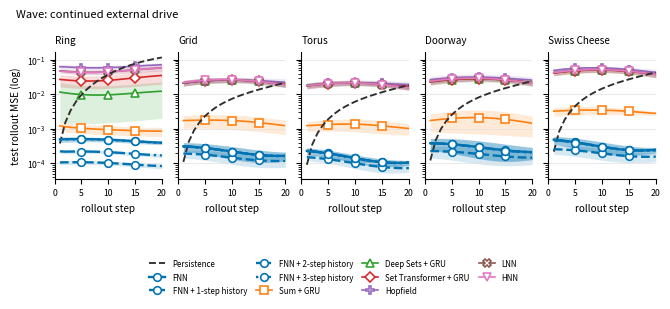

Saved ../derived/figures/second_order_wave_trainroll1_cutoff_rollout.pdf and ../derived/figures/second_order_wave_trainroll1_cutoff_rollout.png


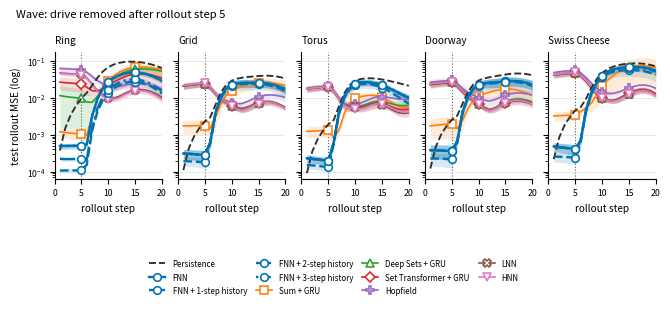

In [ ]:
IFT_BLUE = "#0072B2"  # Matches the generic first-order FNN.
MODEL_LABELS = {
    "ift2_auto": "FNN (2nd-order)",
    "ift2_hist_vel_k1": "FNN + 1-step history",
    "ift2_hist_vel_k2": "FNN + 2-step history",
    "ift2_hist_vel_k3": "FNN + 3-step history",
    "sum/tgn_gru": "GRU",
    "deepsets/tgn_gru": "Deep Sets",
    "settransformer/tgn_gru": "Set Transformer",
    "hopfield/hopfield_update": "Hopfield",
    "settransformer/lnn": "LNN",
    "settransformer/hnn": "HNN",
}

IFT_STYLES = {
    "ift2_auto": {"label": MODEL_LABELS["ift2_auto"], "color": IFT_BLUE, "linestyle": "-"},
    "ift2_hist_vel_k1": {"label": "FNN + 1-step history", "color": IFT_BLUE, "linestyle": "--"},
    "ift2_hist_vel_k2": {"label": "FNN + 2-step history", "color": IFT_BLUE, "linestyle": "-."},
    "ift2_hist_vel_k3": {"label": "FNN + 3-step history", "color": IFT_BLUE, "linestyle": ":"},
}
BASELINE_STYLES = {
    run: {"label": MODEL_LABELS[run]}
    for run in ("sum/tgn_gru", "deepsets/tgn_gru", "settransformer/tgn_gru", "hopfield/hopfield_update", "settransformer/lnn", "settransformer/hnn")
}
# The main model comparison uses only the base FNN.  History-conditioned
# variants have access to recent observed targets and therefore belong in
# the dedicated ablation below, rather than in the rollout-training panel.
# Match rollout_curves.ipynb exactly: baseline color and marker assignment
# follows the alphabetically sorted run names after the blue FNN entry.
DISPLAY_RUNS = ("ift2_auto",) + tuple(sorted(BASELINE_STYLES))
BASELINE_COLORS = plt.get_cmap("tab10").colors
MODEL_MARKERS = ("o", "s", "^", "D", "P", "X", "v", "h")
MARKER_STEPS = (5, 10, 15)

def aggregate_seed_curves(seed_curves):
    steps = sorted({step for curve in seed_curves.values() for step in curve})
    mean, lower, upper = [], [], []
    for step in steps:
        values = [curve[step] for curve in seed_curves.values() if step in curve]
        center = sum(values) / len(values)
        sem = 0.0 if len(values) < 2 else (sum((value - center) ** 2 for value in values) / (len(values) - 1)) ** 0.5 / len(values) ** 0.5
        mean.append(center)
        lower.append(max(center - sem, 1e-12))
        upper.append(max(center + sem, 1e-12))
    return steps, mean, lower, upper

def plot_topology(axis, panel, persistence_by_seed, title, *, cutoff=False):
    handles, labels = [], []
    if persistence_by_seed:
        steps, mean, _, _ = aggregate_seed_curves(persistence_by_seed)
        line, = axis.plot(steps, mean, color="0.2", linewidth=1.6, linestyle="--", label="persistence", zorder=3)
        handles.append(line); labels.append("persistence")
    for index, run in enumerate(DISPLAY_RUNS):
        if run not in panel:
            continue
        is_ift = run in IFT_STYLES
        style = IFT_STYLES.get(run, BASELINE_STYLES.get(run, {"label": run}))
        color = style["color"] if is_ift else BASELINE_COLORS[index % len(BASELINE_COLORS)]
        steps, mean, lower, upper = aggregate_seed_curves(panel[run])
        marker_indices = [steps.index(step) for step in MARKER_STEPS if step in steps]
        axis.fill_between(steps, lower, upper, color=color, alpha=0.16, linewidth=0, zorder=1)
        line, = axis.plot(steps, mean, label=style["label"], color=color, linestyle=style.get("linestyle", "-"), linewidth=1.7 if is_ift else 1.2, marker=MODEL_MARKERS[index % len(MODEL_MARKERS)], markersize=5.5, markerfacecolor="white", markeredgecolor=color, markeredgewidth=1.15, markevery=marker_indices, zorder=4 if is_ift else 2)
        handles.append(line); labels.append(style["label"])
    axis.set_title(title.replace("swisscheese", "Swiss cheese").title(), loc="left")
    axis.set_xlim(0, MAX_STEP)
    axis.set_xticks(range(0, MAX_STEP + 1, 5))
    axis.set_yscale("log")
    axis.grid(axis="y", color="0.88", linewidth=0.5)
    axis.grid(axis="x", visible=False)
    axis.spines[["top", "right"]].set_visible(False)
    if cutoff:
        axis.axvline(CUTOFF, color="0.35", linewidth=0.8, linestyle=":", zorder=0)
    return handles, labels

def export_condition(dynamic, condition, *, title):
    available_topologies = [topology for topology in TOPOLOGY_ORDER if topology in data[dynamic] and data[dynamic][topology][condition]]
    if not available_topologies:
        print(f"Skipping {dynamic}/{condition}: no data.")
        return
    fig, axes = plt.subplots(1, len(available_topologies), figsize=(6.5, 2.65), sharey=True, constrained_layout=False)
    axes = [axes] if len(available_topologies) == 1 else list(axes)
    legend_handles, legend_labels = [], []
    for axis, topology in zip(axes, available_topologies):
        topology_data = data[dynamic][topology]
        handles, labels = plot_topology(axis, topology_data[condition], topology_data[f"{condition}_persistence"], topology, cutoff=(condition == "cutoff"))
        if not legend_handles:
            legend_handles, legend_labels = handles, labels
    axes[0].set_ylabel("test rollout MSE (log)")
    for axis in axes:
        axis.set_xlabel("rollout step")
    fig.suptitle(title, x=0.01, ha="left", fontsize=9)
    fig.legend(legend_handles, legend_labels, loc="lower center", ncol=4, frameon=False, handlelength=1.8, columnspacing=1.0, bbox_to_anchor=(0.5, 0.0))
    fig.subplots_adjust(left=0.07, right=0.995, top=0.82, bottom=0.34, wspace=0.15)
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)
    stem = EXPORT_DIR / f"second_order_{dynamic}_trainroll{TRAIN_ROLLOUT}_{condition}_rollout"
    fig.savefig(stem.with_suffix(".pdf"), bbox_inches="tight")
    fig.savefig(stem.with_suffix(".png"), dpi=600, bbox_inches="tight")
    print(f"Saved {stem.with_suffix('.pdf')} and {stem.with_suffix('.png')}")
    plt.show()

for dynamic in selected_dynamics:
    export_condition(dynamic, "driven", title="")
    export_condition(dynamic, "cutoff", title=f"{dynamic.replace('_', ' ').title()}: drive removed after rollout step {CUTOFF}")


## Rollout-training grid

Each row is one differentiable training-unroll length and each column is one evaluation rollout step. The cells aggregate seeds, so this reveals where longer self-fed training changes long-horizon behavior. This first view intentionally uses only the base `ift2_auto` FNN; history-conditioned variants can be compared separately after establishing the basic effect.

Saved ../derived/figures/second_order_wave_ift2_auto_trainroll_grid_driven.pdf and ../derived/figures/second_order_wave_ift2_auto_trainroll_grid_driven.png


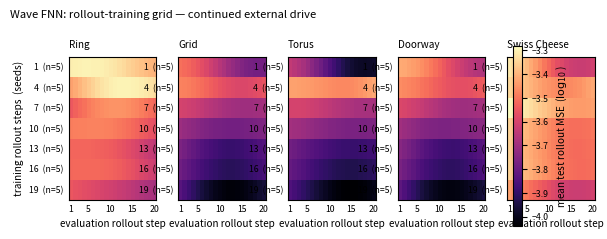

Saved ../derived/figures/second_order_wave_ift2_auto_trainroll_grid_cutoff.pdf and ../derived/figures/second_order_wave_ift2_auto_trainroll_grid_cutoff.png


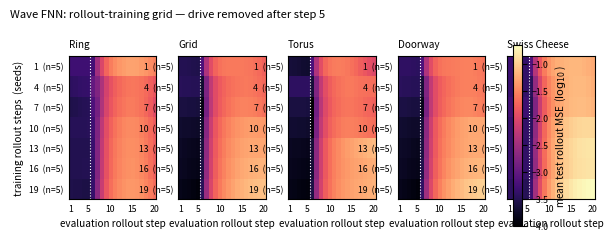

In [4]:
HEATMAP_RUN = "ift2_auto"
HEATMAP_DYNAMICS = selected_dynamics

# dynamic -> topology -> trainroll -> condition -> seed -> step -> MSE
heatmap_data = defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(dict))))
for path in sorted(RESULTS_DIR.glob("second_order_*.jsonl")):
    match = PATH_RE.match(path.name)
    if not match:
        continue
    info = match.groupdict()
    if int(info["cutoff"]) != CUTOFF or info["dynamic"] not in HEATMAP_DYNAMICS:
        continue
    rows = [json.loads(line) for line in path.read_text(encoding="utf-8").splitlines() if line.strip()]
    dynamic, topology = info["dynamic"], info["topology"]
    trainroll, seed = int(info["trainroll"]), info["seed"]
    for condition, block_name in (("driven", "rollout_test"), ("cutoff", "rollout_intervention_test")):
        row = final_rows_for_block(rows, block_name).get(HEATMAP_RUN)
        if row is None:
            continue
        heatmap_data[dynamic][topology][trainroll][condition][seed] = {
            int(step): values[METRIC]
            for step, values in row[block_name]["rollout_by_step"].items()
            if int(step) <= MAX_STEP and values.get(METRIC) is not None
        }

def heatmap_matrix(by_trainroll, condition):
    trainrolls = sorted(trainroll for trainroll, values in by_trainroll.items() if values[condition])
    matrix = np.full((len(trainrolls), MAX_STEP), np.nan)
    seed_counts = []
    for row_index, trainroll in enumerate(trainrolls):
        seed_curves = by_trainroll[trainroll][condition]
        seed_counts.append(len(seed_curves))
        for step in range(1, MAX_STEP + 1):
            values = [curve[step] for curve in seed_curves.values() if step in curve]
            if values:
                matrix[row_index, step - 1] = np.mean(values)
    return trainrolls, seed_counts, matrix

def export_heatmaps(dynamic, condition):
    topologies = [topology for topology in TOPOLOGY_ORDER if topology in heatmap_data[dynamic]]
    matrices = []
    for topology in topologies:
        trainrolls, counts, matrix = heatmap_matrix(heatmap_data[dynamic][topology], condition)
        if matrix.size:
            matrices.append((topology, trainrolls, counts, matrix))
    if not matrices:
        print(f"Skipping {dynamic}/{condition}: no {HEATMAP_RUN} rollout-training grid.")
        return
    finite_values = np.concatenate([matrix[np.isfinite(matrix)] for _, _, _, matrix in matrices])
    vmin, vmax = np.log10(finite_values).min(), np.log10(finite_values).max()
    fig, axes = plt.subplots(1, len(matrices), figsize=(6.5, 2.6), sharey=False, constrained_layout=False)
    axes = [axes] if len(matrices) == 1 else list(axes)
    image = None
    for axis, (topology, trainrolls, counts, matrix) in zip(axes, matrices):
        image = axis.imshow(np.log10(matrix), aspect="auto", interpolation="nearest", cmap="magma", vmin=vmin, vmax=vmax)
        axis.set_title(topology.replace("swisscheese", "Swiss cheese").title(), loc="left")
        axis.set_xticks([0, 4, 9, 14, 19], labels=[1, 5, 10, 15, 20])
        axis.set_yticks(range(len(trainrolls)), labels=[f"{trainroll}  (n={count})" for trainroll, count in zip(trainrolls, counts)])
        axis.tick_params(length=0)
        if condition == "cutoff":
            axis.axvline(CUTOFF - 0.5, color="white", linewidth=0.8, linestyle=":")
    axes[0].set_ylabel("training rollout steps  (seeds)")
    for axis in axes:
        axis.set_xlabel("evaluation rollout step")
    condition_title = "continued external drive" if condition == "driven" else f"drive removed after step {CUTOFF}"
    fig.suptitle(f"{dynamic.replace('_', ' ').title()} FNN: rollout-training grid — {condition_title}", x=0.01, ha="left", fontsize=9)
    colorbar = fig.colorbar(image, ax=axes, shrink=0.9, pad=0.02)
    colorbar.set_label("mean test rollout MSE  ($\log_{10}$)")
    fig.subplots_adjust(left=0.10, right=0.91, top=0.80, bottom=0.25, wspace=0.25)
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)
    stem = EXPORT_DIR / f"second_order_{dynamic}_{HEATMAP_RUN}_trainroll_grid_{condition}"
    fig.savefig(stem.with_suffix(".pdf"), bbox_inches="tight")
    fig.savefig(stem.with_suffix(".png"), dpi=600, bbox_inches="tight")
    print(f"Saved {stem.with_suffix('.pdf')} and {stem.with_suffix('.png')}")
    plt.show()

for dynamic in HEATMAP_DYNAMICS:
    export_heatmaps(dynamic, "driven")
    export_heatmaps(dynamic, "cutoff")


## History-length ablation

The history-conditioned models are separated from the main FNN-versus-baseline comparison because they construct a velocity estimate from recent observed target states. This ablation compares that design choice directly with the base `ift2_auto` model, holding the training rollout length fixed.


In [ ]:
ABLATION_TRAIN_ROLLOUT = TRAIN_ROLLOUT  # Usually 1 for the headline driven ablation.
ABLATION_RUNS = ("ift2_auto", "ift2_hist_vel_k1", "ift2_hist_vel_k2", "ift2_hist_vel_k3")

if ABLATION_TRAIN_ROLLOUT != TRAIN_ROLLOUT:
    raise ValueError(
        "Set TRAIN_ROLLOUT to ABLATION_TRAIN_ROLLOUT and rerun the data-loading cell before plotting this ablation."
    )

def export_history_ablation(dynamic, condition):
    topologies = [
        topology for topology in TOPOLOGY_ORDER
        if topology in data[dynamic] and any(run in data[dynamic][topology][condition] for run in ABLATION_RUNS)
    ]
    if not topologies:
        print(f"Skipping {dynamic}/{condition}: no history-ablation data.")
        return
    fig, axes = plt.subplots(1, len(topologies), figsize=(6.5, 2.45), sharey=True, constrained_layout=False)
    axes = [axes] if len(topologies) == 1 else list(axes)
    handles, labels = [], []
    for axis, topology in zip(axes, topologies):
        panel = data[dynamic][topology][condition]
        if data[dynamic][topology][f"{condition}_persistence"]:
            steps, mean, _, _ = aggregate_seed_curves(data[dynamic][topology][f"{condition}_persistence"])
            line, = axis.plot(steps, mean, color="0.2", linewidth=1.6, linestyle="--", label="persistence", zorder=3)
            if not handles:
                handles.append(line); labels.append("persistence")
        for run in ABLATION_RUNS:
            if run not in panel:
                continue
            style = IFT_STYLES[run]
            steps, mean, lower, upper = aggregate_seed_curves(panel[run])
            marker_indices = [steps.index(step) for step in MARKER_STEPS if step in steps]
            axis.fill_between(steps, lower, upper, color=style["color"], alpha=0.14, linewidth=0, zorder=1)
            line, = axis.plot(
                steps, mean, label=style["label"], color=style["color"], linestyle=style["linestyle"],
                linewidth=1.7, marker="o", markersize=5.5, markerfacecolor="white",
                markeredgecolor=style["color"], markeredgewidth=1.15, markevery=marker_indices, zorder=4,
            )
            if topology == topologies[0]:
                handles.append(line); labels.append(style["label"])
        axis.set_title(topology.replace("swisscheese", "Swiss cheese").title(), loc="left")
        axis.set_xlim(0, MAX_STEP); axis.set_xticks(range(0, MAX_STEP + 1, 5)); axis.set_yscale("log")
        axis.grid(axis="y", color="0.88", linewidth=0.5); axis.grid(axis="x", visible=False)
        axis.spines[["top", "right"]].set_visible(False)
        if condition == "cutoff":
            axis.axvline(CUTOFF, color="0.35", linewidth=0.8, linestyle=":", zorder=0)
    axes[0].set_ylabel("test rollout MSE (log)")
    for axis in axes:
        axis.set_xlabel("rollout step")
    condition_title = "continued external drive" if condition == "driven" else f"drive removed after rollout step {CUTOFF}"
    fig.suptitle(f"{dynamic.replace('_', ' ').title()}: velocity-history ablation — {condition_title}", x=0.01, ha="left", fontsize=9)
    fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False, handlelength=1.8, columnspacing=1.2, bbox_to_anchor=(0.5, 0.0))
    fig.subplots_adjust(left=0.07, right=0.995, top=0.80, bottom=0.36, wspace=0.15)
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)
    stem = EXPORT_DIR / f"second_order_{dynamic}_trainroll{ABLATION_TRAIN_ROLLOUT}_{condition}_history_ablation"
    fig.savefig(stem.with_suffix(".pdf"), bbox_inches="tight")
    fig.savefig(stem.with_suffix(".png"), dpi=600, bbox_inches="tight")
    print(f"Saved {stem.with_suffix('.pdf')} and {stem.with_suffix('.png')}")
    plt.show()

for dynamic in selected_dynamics:
    export_history_ablation(dynamic, "driven")
    export_history_ablation(dynamic, "cutoff")
